# Feature extraction: PCA

Autores: Pablo Hernández Cámara (pablo.hernandez-camara@uv.es) y Pedro Ramón Ventura Gómez (pventura@march-am.com)

En este notebook vamos a ver el método más famoso de reducción de dimensionalidad, en particular de feature extraction, Principal Component Analysis (PCA).

Recordad que la feature extraction tiene como objetivo reducir el número de variables de nuestros datos generando nuevas variables a partir de las originales.

## PCA a mano

Como hemos visto, PCA busca las direcciones principales de nuestros datos. Esto es, las direcciones que maximizan la varianza, es decir, que mejor expresan los datos. Vamos a hacerlo primero a mano.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns

Generamos unos datos falsos

In [ ]:
X = np.array([[1,2],[3,3],[3,5],[5,4],[5,6],[6,5],[8,7],[9,8]])
print(X.shape)

(8, 2)


**Ejercicio: Representa los datos.**

Lo primero que hemos de hacer es calcular la matriz de covarianza, que nos indica como están relacionadas las distintas variables. Podemos hacerlo "a mano" o usando la función de numpy.

**Ejercicio: Calcula la matriz de covarianza. Recuerda que se calcula como X.T $\times$ X**

**Ejercicio: ¿Que nos indica cada uno de los valores de esta matriz?**

El siguiente paso es calcular sus valores y vectores propios, diagonalizando la matriz. También podríamos resolverlo "a mano" es mucho más rápido con la función de Numpy ``np.linalg.eig``

In [ ]:
la, v = np.linalg.eig(cov)

print('Autovalores:')
print(la)

Autovalores:
[9.3418921 0.4081079]


La función de numpy ya nos da los vectores propios puestos en columnas de una matriz, para que podamos usarla directamente como matriz de transformación de nuestros datos.

In [ ]:
print('Matriz')
print(v)

Matriz
[[ 0.80864711 -0.58829402]
 [ 0.58829402  0.80864711]]


Por definición, estos vectores tienen que ser ortogonales y con norma unidad. Vamos a comprobarlo.

**Ejercicio: Comprueba que los vectores son ortonormales.**

Vamos a ver como son estas direcciones.

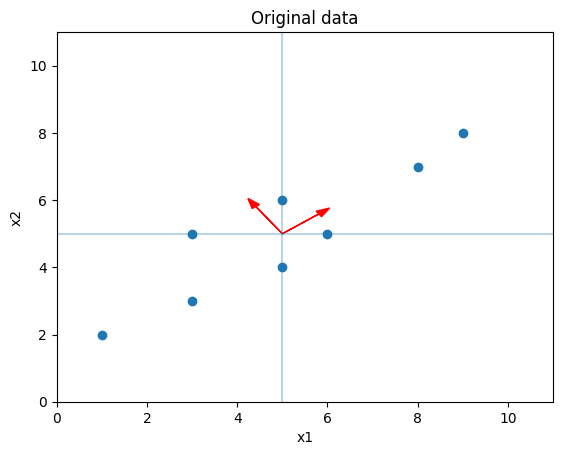

In [ ]:
plt.plot(X[:,0], X[:,1], 'o')
plt.arrow(X[:,0].mean(), X[:,1].mean(), float(v[0,0]), float(v[1,0]), head_width=0.2, head_length=0.3, fc='r', ec='r')
plt.arrow(X[:,0].mean(), X[:,1].mean(), float(v[0,1]), float(v[1,1]), head_width=0.2, head_length=0.3, fc='r', ec='r')
plt.hlines(X[:,0].mean(), 0, 11, alpha=0.3)
plt.vlines(X[:,1].mean(), 0, 11, alpha=0.3)
plt.xlim([0,11])
plt.ylim([0,11])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Original data')
plt.show()

Para transformar los datos originales a estas nuevas direcciones simplemente hemos de multiplicar matricialmente (matematicamente es una rotación).

In [ ]:
X_transformed = X @ v
print(X_transformed.shape)

(8, 2)


Vamos a representarlos ahora.

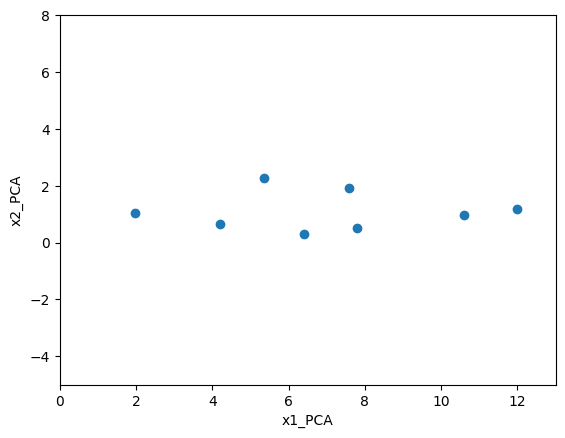

In [ ]:
plt.plot(X_transformed[:,0],X_transformed[:,1],'o')
plt.xlim([0,13])
plt.ylim([-5,8])
plt.xlabel('x1_PCA')
plt.ylabel('x2_PCA')
plt.show()

**Ejercicios: En estos datos transformados, ¿con que variable te quedarias?**

**Ejercicio: ¿Como es la matriz de covarianza de los datos transformados? ¿Te suenan los valores?**

PCA es un método de redución de la dimensionalidad. Para ello, hemos de eliminar las dimensiones menos informativas. Para ver con que dimensión nos quedamos tenemos que fijarnos en los autovalores, ya que indican la cantidad de varianza que explica cada dimensión: Queremos eliminar las dimensiones que menos nos aportan, que menos varianza explican. Vamos a comprobar que autovalor es el máximo.

In [ ]:
print('Autovalores:')
print(la)

Autovalores:
[9.3418921 0.4081079]


In [ ]:
print('Porcentaje de varianza explicada por cada dimensión del PCA:')
print(100*la/np.sum(la))

Porcentaje de varianza explicada por cada dimensión del PCA:
[95.81427791  4.18572209]


In [ ]:
val = list(la).index(max(la))
print('Posicion en la que se encuentra el mayor autovalor:')
print(val)

Posicion en la que se encuentra el mayor autovalor:
0


Si queremos bajar las dimensiones a 1 (única opción posible en este caso ya que tenemos solo 2 dimensiones) nos quedaremos solo con el vector que tiene el mayor autovalor para quedarnos solo con esa dimensión.

In [ ]:
print('Matriz')
print(v)

Matriz
[[ 0.80864711 -0.58829402]
 [ 0.58829402  0.80864711]]


In [ ]:
U = v[:,val].reshape(2,1)
print('Matriz U:')
print(U)

Matriz U:
[[0.80864711]
 [0.58829402]]


Y al transformar ahora los datos tendremos solo una dimensión.

**Ejercicio: Transforma ahora los datos a la dirección que explica la mayor varianza de los datos.**

**Ejercicio: Calcula la varianza de estos datos con ``np.var``. ¿Te suena el valor?**

Vamos a verlo todo representado.

/tmp/ipykernel_324/2578586941.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.arrow(X[:,0].mean(), X[:,1].mean(), float(U[0]), float(U[1]), head_width=0.2, head_length=0.3, fc='r', ec='r')
/tmp/ipykernel_324/2578586941.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.arrow(X[:,0].mean(), X[:,1].mean(), float(U[0]), float(U[1]), head_width=0.2, head_length=0.3, fc='r', ec='r')


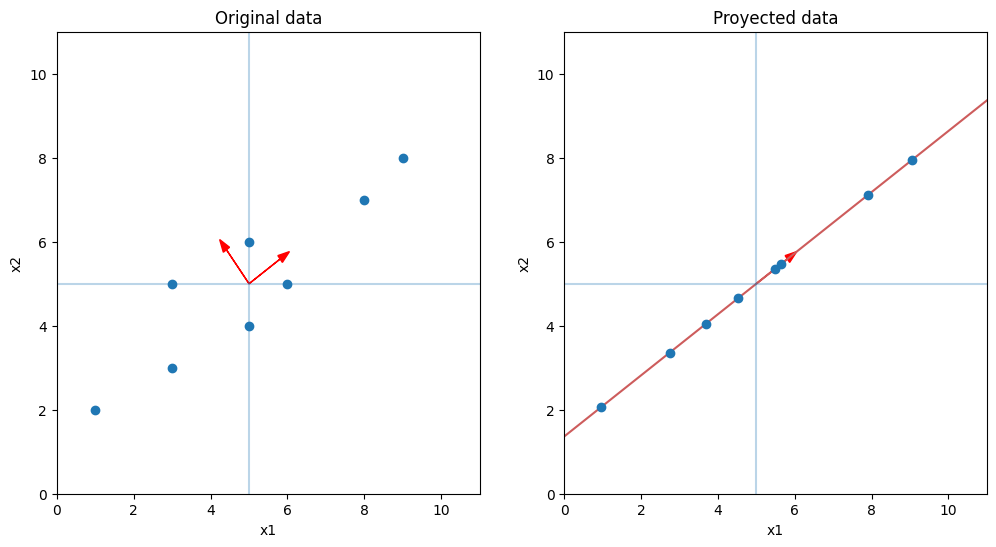

In [ ]:
plt.figure(figsize = (12,6))
plt.subplot(121)
plt.plot(X[:,0], X[:,1], 'o')
plt.arrow(X[:,0].mean(), X[:,1].mean(), float(U[0]), float(U[1]), head_width=0.2, head_length=0.3, fc='r', ec='r')
plt.arrow(X[:,0].mean(), X[:,1].mean(), float(v[0,1]), float(v[1,1]), head_width=0.2, head_length=0.3, fc='r', ec='r')
plt.hlines(X[:,0].mean(), 0, 11, alpha=0.3)
plt.vlines(X[:,1].mean(), 0, 11, alpha=0.3)
plt.xlim([0,11])
plt.ylim([0,11])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Original data')

plt.subplot(122)
t = [-10, 10]
plt.plot(X[:,0].mean() + U[0]*t, X[:,1].mean() + U[1]*t, 'IndianRed')
plt.arrow(X[:,0].mean(), X[:,1].mean(), float(U[0]), float(U[1]), head_width=0.2, head_length=0.3, fc='r', ec='r')
plt.plot(X[:,0].mean() + U[0]*(X_transformed_1-X_transformed_1.mean()), X[:,1].mean() + U[1]*(X_transformed_1-X_transformed_1.mean()), 'o')
plt.hlines(X[:,0].mean(), 0, 11, alpha=0.3)
plt.vlines(X[:,1].mean(), 0, 11, alpha=0.3)
plt.xlim([0,11])
plt.ylim([0,11])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Proyected data')
plt.show()

**Ejercicio: Ejecuta el siguiente codigo. ¿Que representa? ¿Que está pasando?**

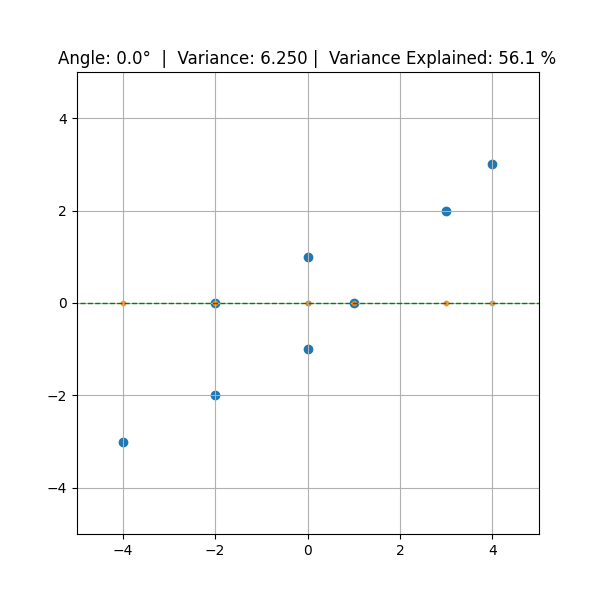

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

X_scaled = X - np.mean(X, axis=0)
la, _ = np.linalg.eig(np.cov(X_scaled.T))

# Prepare figure
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X_scaled[:,0], X_scaled[:,1])

# Rotating axis
line, = ax.plot([], [], 'g--', lw=1)
proj_scatter = ax.scatter(np.zeros_like(X_scaled[:,0]), np.zeros_like(X_scaled[:,1]), s=10, alpha=0.8)

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.grid(True)

# Dynamic title
title = ax.set_title("")

# Animation function
def update(frame):
    theta = np.deg2rad(frame)  # angle in radians
    axis = np.array([np.cos(theta), np.sin(theta)])  # unit vector

    # Line for the current axis
    line_points = np.array([[-8*axis[0], -8*axis[1]],
                            [ 8*axis[0],  8*axis[1]]])
    line.set_data(line_points[:,0], line_points[:,1])

    # 1D projection
    proj_coords = np.dot(X_scaled, axis)   # 1D coordinates along axis


    # Variance of the data projected onto the current axis
    var_axis = np.var(proj_coords)

    # Explained variance of the current axis

    var_explained = 100*var_axis/np.sum(la)


    # Projected points in 2D along the current axis (only for plotting)
    X_proj = np.outer(proj_coords, axis)
    proj_scatter.set_offsets(X_proj)

    # Update title with variance
    title.set_text(f"Angle: {frame:.1f}°  |  Variance: {var_axis:.3f} |  Variance Explained: {var_explained:.1f} %")

    return line, proj_scatter, title


ani = FuncAnimation(fig, update, frames=np.linspace(0, 180, 90),
                    interval=100, blit=True)

ani.save("projection.gif", writer="pillow", fps=5)

plt.close(fig)

from IPython.display import Image
Image(filename="projection.gif")


## PCA Sklearn


Vamos a ver ahora como se hace con los mismos datos pero usando la función de Sklearn que hace PCA.

In [ ]:
from sklearn.decomposition import PCA

Lo primero hemos de definir con cuantas dimensiones queremos quedarnos. Si ponemos las mismas que tienen los datos originales, no hacemos reducción, es simplemente una rotación. Si bajamos el número ya estamos reduciendo la dimensionalidad.

**Ejercicio: Usa el PCA de sklearn para bajar directamente a una única variable.**

**Ejercicio: ¿Coincide con lo que hemos hecho a mano?**

Falta restar la media, la función de sklearn centra los datos también.

In [ ]:
print('Resultado a mano, restando la media para centrarlo:')
print(X_transformed_1 - X_transformed_1.mean())

Resultado a mano, restando la media para centrarlo:
[[-4.99947049]
 [-2.79388226]
 [-1.61729421]
 [-0.58829402]
 [ 0.58829402]
 [ 0.80864711]
 [ 3.60252936]
 [ 4.99947049]]


Y como PCA en realidad lo que hace es una transformación de los datos, podemos "desrotarlos" y volver a los originales.

In [ ]:
X_restored = pca.inverse_transform(X_transformed_sklearn)
print(X_restored)

[[0.95719265 2.05884139]
 [2.7407352  3.35637577]
 [3.69217971 4.04855548]
 [4.52427774 4.65391014]
 [5.47572226 5.34608986]
 [5.65391014 5.47572226]
 [7.91317495 7.11934649]
 [9.04280735 7.94115861]]


Pero... **¿coinciden con los originales? ¿Por que?**

**Ejercicio: Vuelve a hacer el PCA pero sin eliminar ninguna dimensión y vuelve al espacio original. ¿Ahora coinciden? ¿Por qué pasa esto?**

## PCA en más dimensiones

Vamos a generar datos de 3 dimensiones, donde dos de ellas estén claramente relacionadas y vamos a ver que obtenemos al aplicar PCA.

In [ ]:
# Generamos datos Gaussianos 3D
mean = [0, 5, 2]
cov = [[25,-1,7], [-1,4,-4],[7,-4,10]]
X = np.random.multivariate_normal(mean,cov,1000)
print(X.shape)

(1000, 3)


In [ ]:
df = pd.DataFrame(X)
df.head()

,0,1,2
0,-0.816340,1.945525,4.587565
1,-3.733741,6.655738,-2.115908
2,-0.390320,6.827033,-1.549407
3,4.248181,9.326132,-2.592785
4,5.956491,4.142491,8.806162


Vemos que tenemos más covarianza en X1 que en X3, y más que en X2. Vemos más claramente la relación entre pares de variables con la siguiente representación.

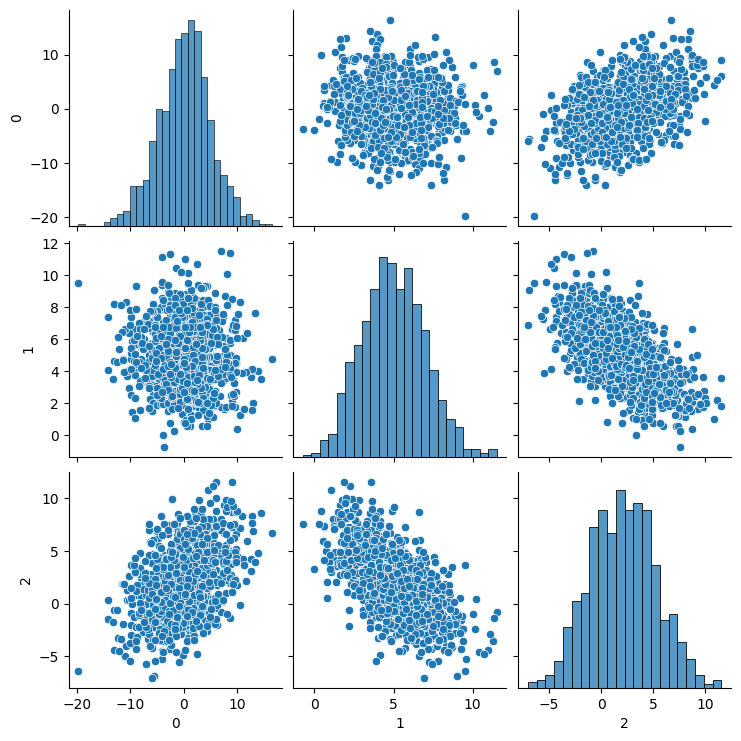

In [ ]:
sns.pairplot(df)
plt.show()

Vamos a hacer una función propia que haga PCA a mano.

**Ejercicio: Completa los huecos de la función.**

In [ ]:
def mypca(X,n_components=0):
    # computing eigenvalues and eigenvectors of covariance matrix from X data
    # D: eigenvalues, U: eigenvectors, Y: projections
    #from numpy import mean,cov,dot,linalg,argsort
    n,p=X.shape
    # subtract the mean
    mean =
    X = (X - mean)
    #compute the covariance matrix
    cov =
    #eigendecomposition
    D, U = np.linalg.eig(cov)
    # sorting the eigenvalues
    lamb = np.argsort(D)
    # in descending order
    order =
    # sorting eigenvectors according to the sorted eigenvalues
    U = U[:,order]
    # sorting eigenvalues
    D = D[order]
    if n_components < p and n_components > 0:
        U = U[:,range(n_components)] # cutting some PCs if needed
    # projection of the data in the new space
    Y =
    return D,U,Y,mean

Ahora vamos a aplicar la función de sklearn y la nuestra para ver si dan lo mismo.

In [ ]:
# sklearn PCA
pca = PCA(n_components = 3)
pca.fit(X)

Upca = pca.components_.T
Dpca = pca.explained_variance_
mupca = pca.mean_
percpca = pca.explained_variance_ratio_
n_componentspca = pca.n_components_
Ypca = pca.transform(X)

print(Dpca,Upca,mupca,percpca,Ypca.shape)

[26.17812354  9.58320454  1.70642865] [[ 0.92185297 -0.36871758 -0.1193082 ]
 [-0.09173471 -0.50672516  0.85721313]
 [ 0.37652602  0.77927977  0.50095029]] [0.08283141 4.99789198 2.09760408] [0.69868404 0.25577204 0.04554392] (1000, 3)


In [ ]:
# Mi PCA
D,U,Y,mu=mypca(X,n_components=0)
perc = D/sum(D)
print(D,U,mu,perc,Y.shape)

[26.15194542  9.57362133  1.70472222] [[ 0.92185297 -0.36871758 -0.1193082 ]
 [-0.09173471 -0.50672516  0.85721313]
 [ 0.37652602  0.77927977  0.50095029]] [0.08283141 4.99789198 2.09760408] [0.69868404 0.25577204 0.04554392] (1000, 3)


**Ejercicio: ¿A alguien le han salido los vectores con otro signo? ¿Esto está mal? ¿Tiene sentido?**

Volvemos a ver la relación en las proyecciones, una vez realizada la PCA, y vemos que las parejas de representaciones ya no presentan correlación, son independientes. Además, la media está centrada en cero, como esperábamos al haber restado la media y realizado la rotación.

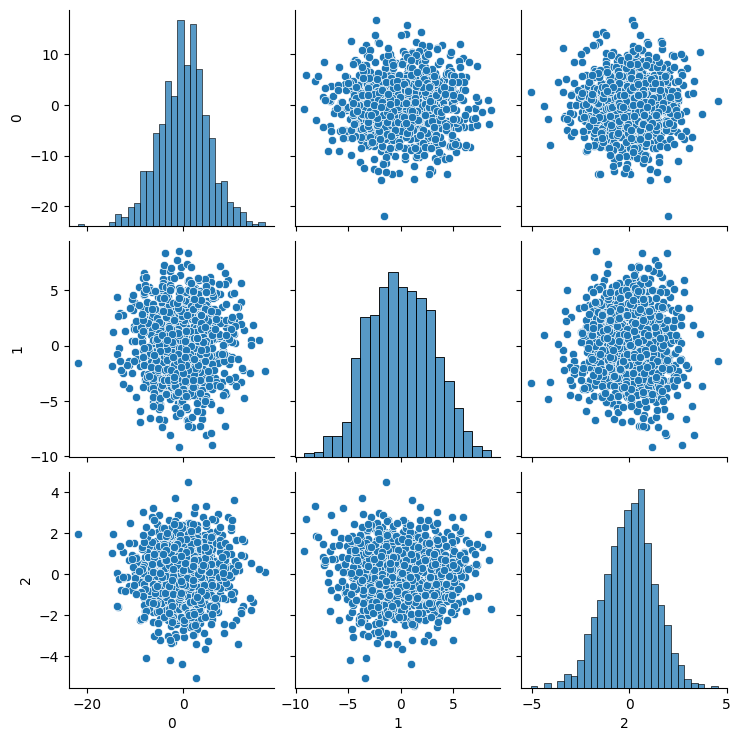

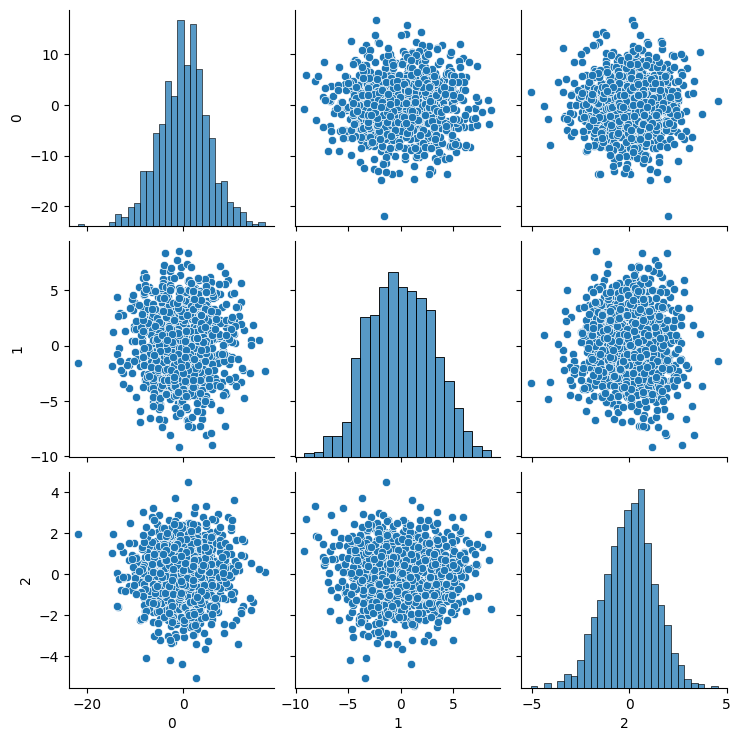

In [ ]:
# pca sklearn
df = pd.DataFrame(Ypca)
sns.pairplot(df)
plt.show()

# mypca
df = pd.DataFrame(Y)
sns.pairplot(df)
plt.show()

**Ejercicio: Comprueba como es la matriz de covarianza de los datos transformados.**

Comprobamos la matriz de covarianza de los datos transformados y vemos que la diagonal coincide con los autovalores y el resto son cero (o casi!).

## PCA on other data types: Face images decomposition

En este ejemplo vamos a ver como podemos aplicar PCA y su correspondiente reducción de dimensionalidad a imagenes, en este caso de caras.

El dataset de olivetti_faces incluye imágenes de 400 caras distintas, donde cada una es un vector de $64\times64 = 4096$ pixeles.

Vamos a cargarlas y realizar los siguientes pasos:

1) Calcular la "cara media" como la media de todo el dataset para restarsela a todas las imagenes, es decir, centramos los datos.

2) A continuación, vamos a calcular los autovectores del PCA y vamos a visualizar los 6 primeros.

3) Vamos a reducir la dimensionalidad de las imágenes usando diferente número de componentes principales (10,30,50,100,200) y vamos a ver el error cometido.

In [ ]:
from sklearn.datasets import fetch_olivetti_faces

dataset_faces = fetch_olivetti_faces().data
n_samples, n_features = dataset_faces.shape
print(n_samples, n_features)

400 4096


Vamos a ver algunas.

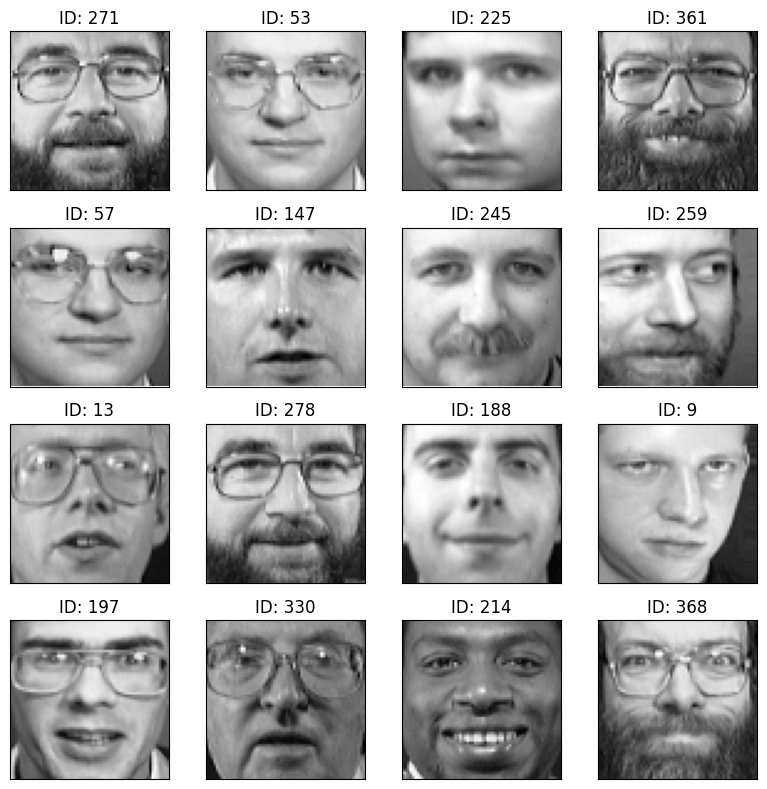

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8), subplot_kw={'xticks':[], 'yticks':[]})

for i, ax in enumerate(axes.flat):
    # Seleccionar una imagen aleatoria
    random_index = np.random.randint(0, n_samples)
    # Reestructurar la imagen a su forma original 64x64
    img = dataset_faces[random_index].reshape(64, 64)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'ID: {random_index}')

plt.tight_layout()
plt.show()

**Ejercicio: Calcula y representa la cara media del dataset.**

Calculamos la "cara media" y la visualizamos.

**Ejercicio: Centra el dataset restandole la cara media. Vuelve a calcular y representar la cara media del dataset centrado. ¿Que esperas que salga? ¿Coincide con lo que te ha salido?**

Y ahora centramos el dataset.

Si repetimos y calculamos la "cara media" del dataset centrado, ¿que nos deberia dar?

Y ahora ya vamos con el PCA.

**Ejercicio: Aplica PCA con las dimensiones por defecto.**

Vamos a ver los primeros autovectores, que podemos pintar tambien en formato imagen.

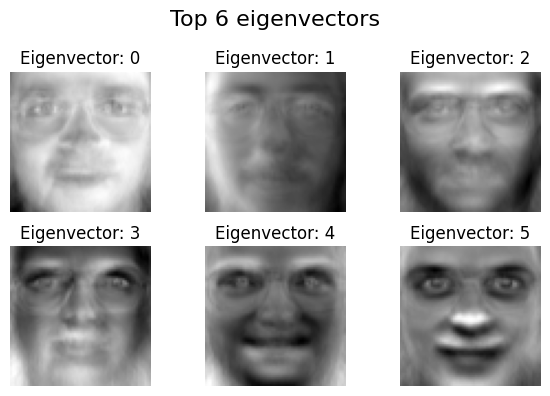

In [ ]:
autovectores_pca = pca.components_

fig, axes = plt.subplots(2, 3, figsize=(6,4))
for i, ax in enumerate(axes.flat):

    # Reestructurar la imagen a su forma original 64x64
    img = autovectores_pca[i].reshape(64, 64)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Eigenvector: {i}')
    ax.axis('off')
plt.suptitle(f'Top {i+1} eigenvectors', size=16)
plt.tight_layout()
plt.show()

Vamos a ver ahora como podemos transformar los datos al dominio de PCA y volver y cuanto error se comete segun cuantas dimensiones mantengamos. Vamos a ver primero la varianza acumulada segun las dimensiones con el PCA que acabamos de hacer.

**Ejercicio: Representa el procentaje de varianza explicada segín el número de dimensiones que mantengamos.**

**Ejercicio: Haz PCA bajando a {1,2,5,10,30,50,100,200} dimensiones. Para cada una de ellas, calcula el ratio de varianza explicada y calcula el error de reconstrucción al volver al espacio original.**

## PCA in real Iris data

In [ ]:
import mpl_toolkits.mplot3d
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data
y = iris.target

print(X.shape, y.shape)

(150, 4) (150,)


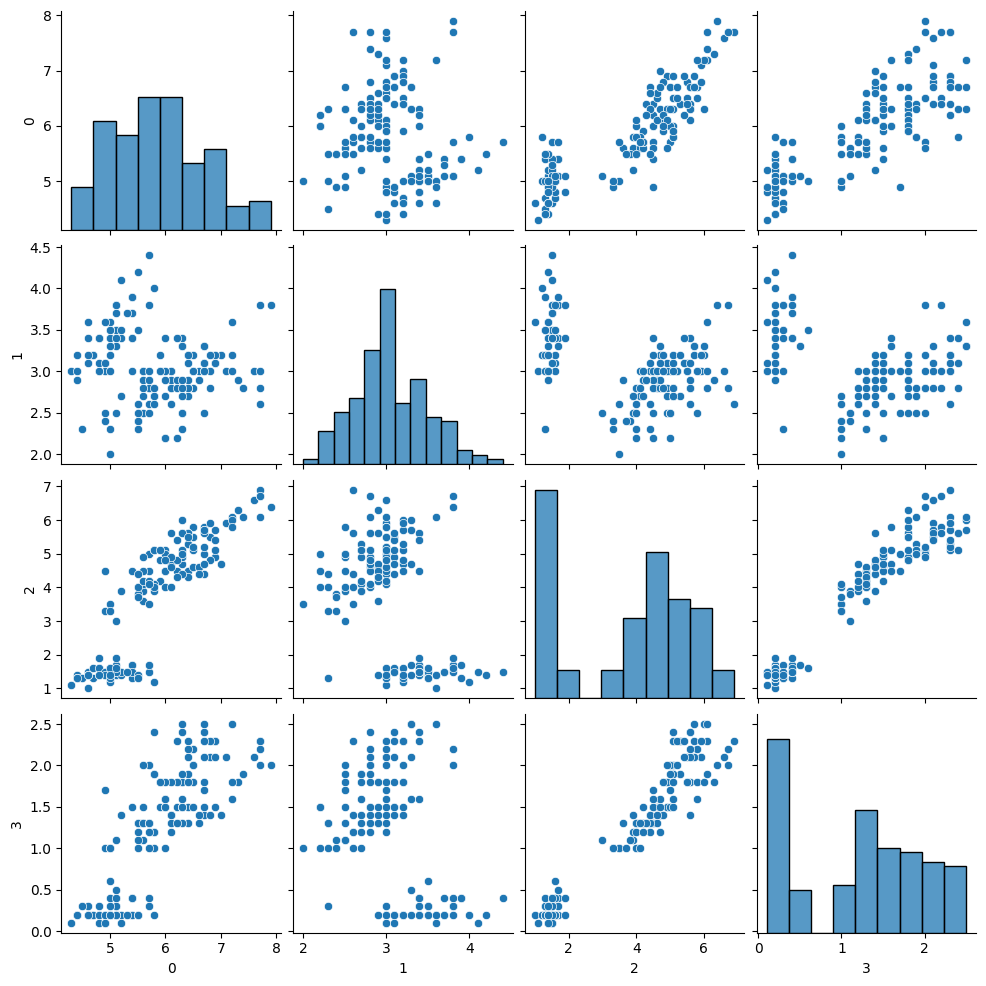

In [ ]:
df = pd.DataFrame(X)
sns.pairplot(df)
plt.show()

**Ejercicio: Realiza PCA para pasar de 4 dimensiones a 3 y poder representarlas.**

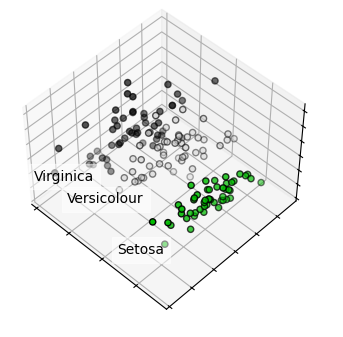

In [ ]:
fig = plt.figure(1, figsize=(4, 3))
plt.clf()

ax = fig.add_subplot(111, projection="3d", elev=48, azim=134)
ax.set_position([0, 0, 0.95, 1])
plt.cla()

for name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.text3D(X_transformed[y == label, 0].mean(),
              X_transformed[y == label, 1].mean() + 1.5,
              X_transformed[y == label, 2].mean(),
              name,
              horizontalalignment="center",
              bbox=dict(alpha=0.5, edgecolor="w", facecolor="w"))

# Reorder the labels to have colors matching the cluster results
y = np.choose(y, [1, 2, 0]).astype(float)
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], X_transformed[:, 2], c=y, cmap=plt.cm.nipy_spectral, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

plt.show()

**Ejercicio: ¿Y bajando a 2 dimensiones?**